In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_percentage_error
)

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv(r"D:\AnalytixLabs\Data Science & AI\6. Case Studies\Machine Learning Case Studies\3. Capstone Case Study - Demand Estimation\Electricity Consumption.csv")

In [5]:
df.head()

,DATE,Electricty_Consumption_in_TW
0,01-01-1973,35.9728
1,02-01-1973,36.1334
2,03-01-1973,35.0625
3,04-01-1973,33.8416
4,05-01-1973,33.5107


In [8]:
df['DATE'] = pd.to_datetime(df['DATE'])

df.set_index('DATE', inplace=True)

df = df.asfreq('MS')

In [10]:
df.isnull().sum()

Electricty_Consumption_in_TW    0
dtype: int64

In [13]:
df.columns = ['Electricity_Consumption']

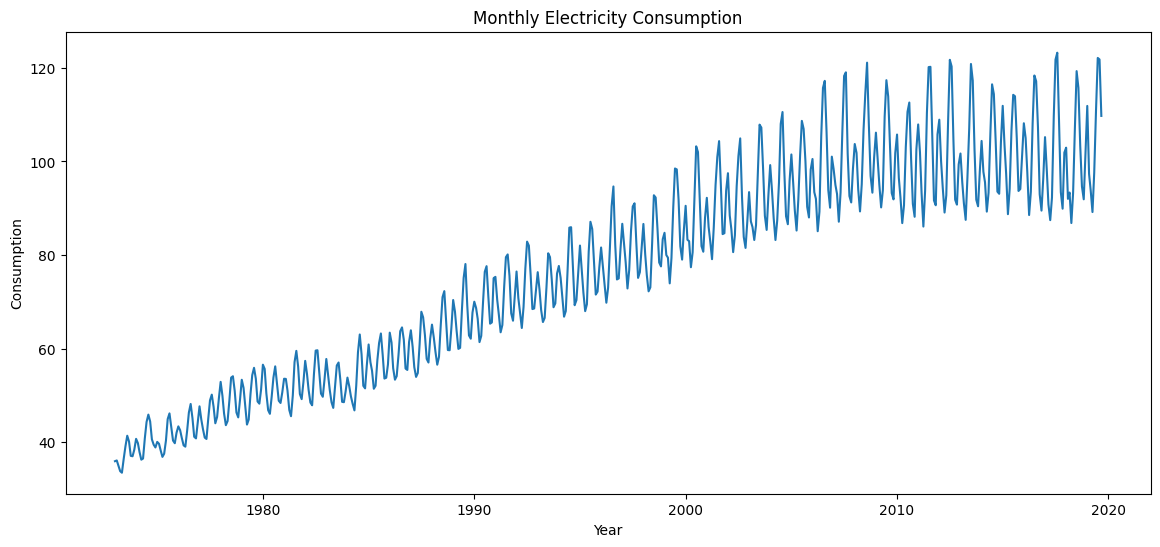

In [15]:
plt.figure(figsize=(14,6))

plt.plot(df['Electricity_Consumption'])

plt.title("Monthly Electricity Consumption")
plt.xlabel("Year")
plt.ylabel("Consumption")

plt.show()

In [16]:
train = df[:'2017-12-01']

test = df['2018-01-01':]

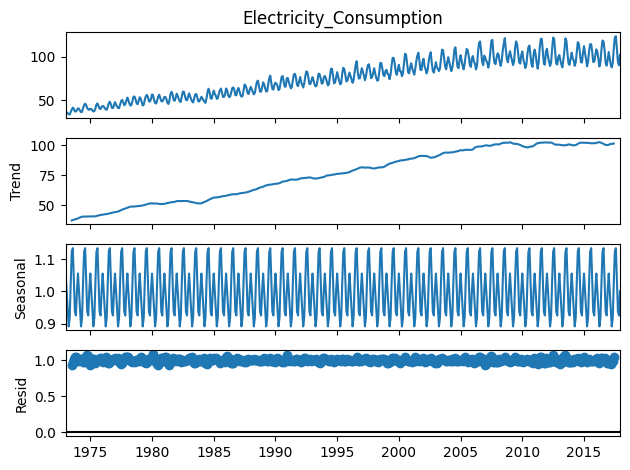

In [17]:
decomposition = seasonal_decompose(
    train['Electricity_Consumption'],
    model='multiplicative',
    period=12
)

decomposition.plot()

plt.show()

In [18]:
# ETS Model

In [51]:
ets_model = ExponentialSmoothing(
    train['Electricity_Consumption'],
    trend='mul',
    seasonal='mul',
    seasonal_periods=12
).fit()

In [52]:
pred_ets = ets_model.forecast(len(test))

In [53]:
pred_ets

2018-01-01    108.695365
2018-02-01    101.595233
2018-03-01     95.039460
2018-04-01     89.244843
2018-05-01     94.806931
2018-06-01    110.096006
2018-07-01    120.801234
2018-08-01    120.236317
2018-09-01    107.660874
2018-10-01     94.542388
2018-11-01     93.030820
2018-12-01    103.232162
2019-01-01    110.794292
2019-02-01    103.557056
2019-03-01     96.874690
2019-04-01     90.968177
2019-05-01     96.637670
2019-06-01    112.221981
2019-07-01    123.133929
2019-08-01    122.558103
2019-09-01    109.739826
Freq: MS, dtype: float64

In [54]:
rmse_ets = np.sqrt(
    mean_squared_error(
        test['Electricity_Consumption'],
        pred_ets
    )
)

mape_ets = mean_absolute_percentage_error(
    test['Electricity_Consumption'],
    pred_ets
) * 100

rmspe_ets = np.sqrt(
    np.mean(
        np.square(
            (
                test['Electricity_Consumption'] - pred_ets
            ) / test['Electricity_Consumption']
        )
    )
) * 100

print("RMSE :", rmse_ets)

print("MAPE :", mape_ets)

print("RMSPE:", rmspe_ets)

RMSE : 3.4193529342584768
MAPE : 2.5334825444134417
RMSPE: 3.5060047470053273


In [56]:
result = adfuller(train['Electricity_Consumption'])

print("ADF Statistic:", result[0])

print("p-value:", result[1])

ADF Statistic: -1.7292885492562067
p-value: 0.4160887994243042


In [57]:
adfuller(np.log(train['Electricity_Consumption']).dropna())

(np.float64(-2.941524872982339),
 np.float64(0.04072793799527538),
 15,
 524,
 {'1%': np.float64(-3.4428912664970523),
  '5%': np.float64(-2.867071538125014),
  '10%': np.float64(-2.5697161081813413)},
 np.float64(-2445.926200751065))

In [58]:
log_train = np.log(train['Electricity_Consumption'])

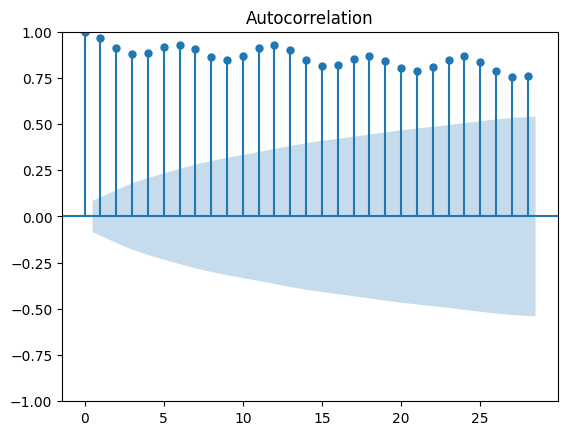

In [59]:
plot_acf(log_train)

plt.show()

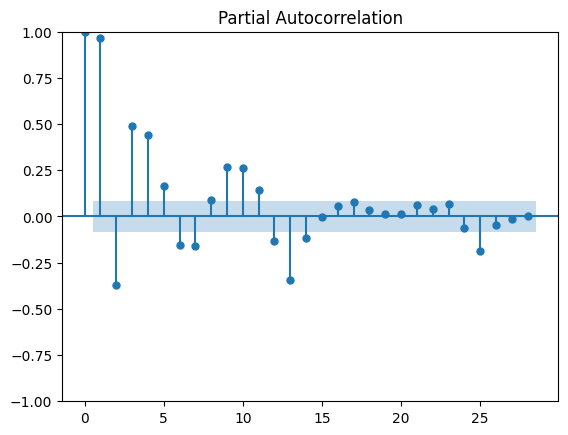

In [60]:
plot_pacf(log_train)

plt.show()

In [61]:
# ARIMA Model

In [62]:
arima_model = ARIMA(
    log_train,
    order=(1,1,1)
).fit()

In [63]:
pred_arima_log = arima_model.forecast(len(test))

In [64]:
pred_arima = np.exp(pred_arima_log)

In [65]:
pred_arima

2018-01-01    112.077929
2018-02-01    113.827211
2018-03-01    114.113864
2018-04-01    114.160485
2018-05-01    114.168058
2018-06-01    114.169288
2018-07-01    114.169487
2018-08-01    114.169520
2018-09-01    114.169525
2018-10-01    114.169526
2018-11-01    114.169526
2018-12-01    114.169526
2019-01-01    114.169526
2019-02-01    114.169526
2019-03-01    114.169526
2019-04-01    114.169526
2019-05-01    114.169526
2019-06-01    114.169526
2019-07-01    114.169526
2019-08-01    114.169526
2019-09-01    114.169526
Freq: MS, Name: predicted_mean, dtype: float64

In [66]:
rmse_arima = np.sqrt(
    mean_squared_error(
        test['Electricity_Consumption'],
        pred_arima
    )
)

mape_arima = mean_absolute_percentage_error(
    test['Electricity_Consumption'],
    pred_arima
) * 100

rmspe_arima = np.sqrt(
    np.mean(
        np.square(
            (
                test['Electricity_Consumption'] - pred_arima
            ) / test['Electricity_Consumption']
        )
    )
) * 100

In [67]:
# SARIMA Model

In [68]:
sarima_model = SARIMAX(
    log_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
).fit()

In [69]:
pred_sarima_log = sarima_model.forecast(len(test))

In [70]:
pred_sarima = np.exp(pred_sarima_log)

In [71]:
pred_sarima

2018-01-01    108.021236
2018-02-01    101.239595
2018-03-01     95.151715
2018-04-01     89.312718
2018-05-01     94.492542
2018-06-01    109.037428
2018-07-01    119.796237
2018-08-01    119.649707
2018-09-01    107.095436
2018-10-01     94.256346
2018-11-01     92.109475
2018-12-01    102.015099
2019-01-01    108.170838
2019-02-01    101.590324
2019-03-01     95.691003
2019-04-01     89.697661
2019-05-01     94.963593
2019-06-01    109.362895
2019-07-01    120.073578
2019-08-01    119.816712
2019-09-01    107.396906
Freq: MS, Name: predicted_mean, dtype: float64

In [72]:
rmse_sarima = np.sqrt(
    mean_squared_error(
        test['Electricity_Consumption'],
        pred_sarima
    )
)

mape_sarima = mean_absolute_percentage_error(
    test['Electricity_Consumption'],
    pred_sarima
) * 100

rmspe_sarima = np.sqrt(
    np.mean(
        np.square(
            (
                test['Electricity_Consumption'] - pred_sarima
            ) / test['Electricity_Consumption']
        )
    )
) * 100

In [73]:
results = pd.DataFrame({
    'Model': ['ETS', 'ARIMA', 'SARIMA'],

    'RMSE': [
        rmse_ets,
        rmse_arima,
        rmse_sarima
    ],

    'MAPE': [
        mape_ets,
        mape_arima,
        mape_sarima
    ],

    'RMSPE': [
        rmspe_ets,
        rmspe_arima,
        rmspe_sarima
    ]
})

print(results)

    Model       RMSE       MAPE      RMSPE
0     ETS   3.419353   2.533483   3.506005
1   ARIMA  15.656376  13.999729  16.775069
2  SARIMA   3.185929   2.409395   3.234807


In [74]:
final_model = SARIMAX(
    np.log(df['Electricity_Consumption']),
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
).fit()

In [75]:
future_forecast_log = final_model.forecast(24)

future_forecast = np.exp(future_forecast_log)

print(future_forecast)

2019-10-01     97.013241
2019-11-01     94.315616
2019-12-01    104.003769
2020-01-01    110.276258
2020-02-01    100.707498
2020-03-01     96.453635
2020-04-01     90.572222
2020-05-01     96.906613
2020-06-01    111.080885
2020-07-01    122.279307
2020-08-01    121.470737
2020-09-01    109.010606
2020-10-01     96.746337
2020-11-01     94.425035
2020-12-01    104.332996
2021-01-01    110.542867
2021-02-01    101.379709
2021-03-01     97.113262
2021-04-01     91.152819
2021-05-01     97.404313
2021-06-01    111.736667
2021-07-01    123.008732
2021-08-01    122.170182
2021-09-01    109.613271
Freq: MS, Name: predicted_mean, dtype: float64


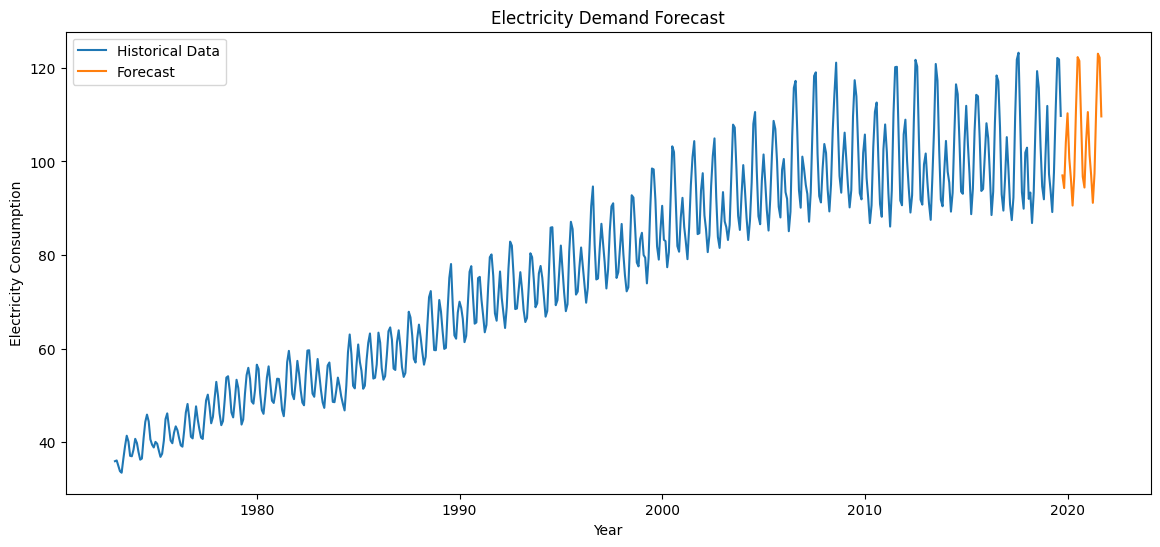

In [76]:
future_dates = pd.date_range(
    start='2019-10-01',
    periods=24,
    freq='MS'
)

plt.figure(figsize=(14,6))

plt.plot(
    df.index,
    df['Electricity_Consumption'],
    label='Historical Data'
)

plt.plot(
    future_dates,
    future_forecast,
    label='Forecast'
)

plt.title("Electricity Demand Forecast")

plt.xlabel("Year")
plt.ylabel("Electricity Consumption")

plt.legend()

plt.show()

In [77]:
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecasted_Consumption': future_forecast
})

forecast_df.to_csv(
    "Electricity_Demand_Forecast.csv",
    index=False
)

print("CSV file saved successfully")

CSV file saved successfully


In [78]:
# Selected Model : SARIMA
# Reason : The SARIMA model was selected because it achieved the best forecasting performance among all the models evaluated.